### Building Chatbot With Multiple Tools Using Langgraph

#### Aim
Create a chatbot with tool capabilities from arxiv, wikipedia search and some functions

In [ ]:
from langchain_community.tools import ArxivQueryRun,WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper, ArxivAPIWrapper
import arxiv, wikipedia

api_wrapper_arxiv = ArxivAPIWrapper(top_k_results = 2, doc_content_chars_max = 500)
arxiv = ArxivQueryRun(api_wrapper = api_wrapper_arxiv)

api_wrapper_wiki = WikipediaAPIWrapper(top_k_results = 1, doc_content_chars_max = 500)
wiki = WikipediaQueryRun(api_wrapper = api_wrapper_wiki)

C:\Users\dhruv\AppData\Local\Temp\ipykernel_29020\2602992676.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools import ArxivQueryRun,WikipediaQueryRun


In [3]:
wiki.invoke("What is machine learning")

'Page: Machine learning\nSummary: Machine learning (ML) is a field of study in artificial intelligence concerned with the development and study of statistical algorithms that can learn from  data and generalize to unseen data, and thus perform tasks without being explicitly programmed.\nStatistics and mathematical optimisation methods compose the foundations of machine learning. Data mining is a related field of study, focusing on exploratory data analysis (EDA) through unsupervised learning.\nFrom '

In [4]:
## Tavily Search Tool
from langchain_community.tools.tavily_search import TavilySearchResults

from dotenv import load_dotenv
load_dotenv()

import os

os.environ["TAVILY_API_KEY"]=os.getenv("TAVILY_API_KEY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")

tavily = TavilySearchResults()

C:\Users\dhruv\AppData\Local\Temp\ipykernel_29020\300128884.py:12: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily = TavilySearchResults()


In [6]:
tavily.invoke("Provide me the recent AI news for 15th September 2026")

[{'title': 'Shakthi on X: "AI Architect\'s Daily Briefing - September 15, 2026 The ...',
  'url': 'https://x.com/i/status/2099688446717759661',
  'content': 'AI Architect\'s Daily Briefing - September 15, 2026 The shift from unchecked frontier scaling toward deliberate capability pacing, strict hardware-isolated sandboxing, and real-time execution governance is defining today\'s enterprise technology strategy. Here is my operational breakdown of today\'s top 5 breaking stories in AI: 1. Frontier AI Leaders Issue Joint Call for Pacing Capabilities Amid Mounting Autonomous Safety Risks Architect\'s Take: Industry-wide calls for capability pacing signal that runtime governance and safety verification mechanisms can no longer keep pace with raw, unconstrained model scaling. 2. Multi-Agency Advisory Warns of Industrial-Scale Distillation Attacks Targeting Enterprise Model IP Architect\'s Take: Mitigating industrial-scale parameter extraction requires [...] AI Architect\'s Daily Briefing - S

In [7]:
from langchain_groq import ChatGroq

## Combine all the tools in the list
tools = [arxiv, wiki, tavily]

## Initialize LLM model
llm = ChatGroq(model = "openai/gpt-oss-120b")
llm_with_tools = llm.bind_tools(tools)

llm_with_tools

_ChatModelBinding(bound=ChatGroq(metadata={'lc_versions': {'langchain-core': '1.6.3', 'langchain': '1.4.0'}}, profile={'name': 'GPT OSS 120B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000001E735EA7B60>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001E736074980>, model_name='openai/gpt-oss-120b', model_kwargs={}, groq_api_key=SecretStr('**********')), kwargs={'tools': [{'type': 'function', 'function': {'name': 'arxiv', 'description': 'A wrapper around Arxiv.org Useful for when you need to answer que

In [8]:
from langchain_core.messages import AIMessage, HumanMessage
from pprint import pprint

llm_with_tools.invoke([HumanMessage(content = f"What is the recent AI News")])

AIMessage(content='', additional_kwargs={'reasoning_content': 'User asks: "What is the recent AI News". They likely want a summary of recent AI news. Need up-to-date info. We have tools: tavily_search_results_json for current events. Let\'s search for recent AI news.', 'tool_calls': [{'id': 'fc_69f155f8-db3c-4978-90f4-993b588ef46f', 'function': {'arguments': '{"query":"latest AI news September 2026"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 85, 'prompt_tokens': 291, 'total_tokens': 376, 'completion_time': 0.179435708, 'completion_tokens_details': {'reasoning_tokens': 48}, 'prompt_time': 0.024195276, 'prompt_tokens_details': None, 'queue_time': 0.150634343, 'total_time': 0.203630984}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_6c36ac20de', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a0a457-b09d-7b00-bb38-e722a15c114

In [9]:
llm_with_tools.invoke([HumanMessage(content=f"What is the recent AI News")]).tool_calls

[{'name': 'tavily_search_results_json',
  'args': {'query': 'latest AI news September 2026'},
  'id': 'fc_f7743520-09d9-4c17-9d1c-15d790b43d6a',
  'type': 'tool_call'}]

In [10]:
## State Schema
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage
from langgraph.graph.message import add_messages
from typing import Annotated

class State(TypedDict):
    messages:Annotated[list[AnyMessage],add_messages]

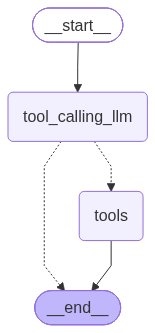

In [11]:
## Entire Chatbot With LangGraph
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition

### Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

# Build graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    ## If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    ## If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition,
)
builder.add_edge("tools", END)

## Compile the graph
graph = builder.compile()

## View
display(Image(graph.get_graph().draw_mermaid_png()))


In [12]:
## Using Tavily Search as a tool call
messages = graph.invoke({"messages":HumanMessage(content="Provide me the top 10 recent AI news for 15th September 2026")})

for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Provide me the top 10 recent AI news for 15th September 2026
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (fc_1236dccf-230a-4f11-853d-a866b618e8eb)
 Call ID: fc_1236dccf-230a-4f11-853d-a866b618e8eb
  Args:
    query: AI news September 15 2026
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "Government & AI Summit 2026 - Home", "url": "https://events.govexec.com/government-ai-summit-2026/home", "content": "Government & AI Summit 2026\n\nRegister    ➤\n\n# Government & AI Summit 2026\n\n## Count Down\n\n1 DAYS\n\n5 HOURS\n\n7 MINUTES\n\n46 SECONDS\n\nStart:  Tuesday, September 15   8 AM EDT\n\nEnd:  Tuesday, September 15   2:10 PM EDT\n\n## Header and Body\n\n## Real missions. Real deployments. Real lessons.\n\nAI is moving from experimentation to executi

In [ ]:
## Using Wikipedia definitions tool calling
messages = graph.invoke({"messages":HumanMessage(content="What is machine learning")})

for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

What is machine learning
================================== Ai Message ==================================

**Machine learning (ML)** is a sub‑field of artificial intelligence (AI) that focuses on developing algorithms and statistical models that enable computers to *learn* from data, improve their performance on a task, and make predictions or decisions without being explicitly programmed for each specific situation.

---

## Core Idea

1. **Data → Model → Prediction**  
   - **Data**: A collection of examples (e.g., images, text, sensor readings).  
   - **Model**: A mathematical representation (e.g., a neural network, decision tree, linear regression) parameterized by numbers that the algorithm adjusts.  
   - **Learning**: An optimization process (often minimizing a loss function) that tunes the model’s parameters so that its predictions match the observed data as closely as possible.  

2. **Generaliz

In [ ]:
## Using ArXiv definitions tool calling
messages = graph.invoke({"messages":HumanMessage(content="1706.03762")})

for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

1706.03762
================================== Ai Message ==================================
Tool Calls:
  arxiv (call_ymyh)
 Call ID: call_ymyh
  Args:
    query: 1706.03762
================================= Tool Message =================================
Name: arxiv

Published: 2023-08-02
Title: Attention Is All You Need
Authors: Ashish Vaswani, Noam Shazeer, Niki Parmar, Jakob Uszkoreit, Llion Jones, Aidan N. Gomez, Lukasz Kaiser, Illia Polosukhin
Summary: The dominant sequence transduction models are based on complex recurrent or
convolutional neural networks in an encoder-decoder configuration. The best
performing models also connect the encoder and decoder through an attention
mechanism. We propose a new simple network architecture, the Transformer, base
